To complete this assignment, fill in any place that says `YOUR CODE HERE` or `YOUR ANSWER HERE`, as well as your name below.

To make sure everything runs as expected, do the following
- **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart)
- **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

A good introduction to Jupyter notebooks is [here](https://realpython.com/jupyter-notebook-introduction/).


In [37]:
NAME = "Petra Dos Santos"

---

<h1>HW2 (50 points)</h1>



<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Part-I:-Word-Vectors" data-toc-modified-id="Part-I:-Word-Vectors-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Part I: Word Vectors</a></span><ul class="toc-item"><li><span><a href="#Using-embeddings-for-classification" data-toc-modified-id="Using-embeddings-for-classification-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Using embeddings for classification</a></span></li><li><span><a href="#Intepreting-word-vector-models" data-toc-modified-id="Intepreting-word-vector-models-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Intepreting word vector models</a></span></li></ul></li><li><span><a href="#Part-II:-Sequence-Models" data-toc-modified-id="Part-II:-Sequence-Models-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Part II: Sequence Models</a></span><ul class="toc-item"><li><span><a href="#transition-probabilities" data-toc-modified-id="transition-probabilities-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>transition probabilities</a></span></li><li><span><a href="#emission-probabilities" data-toc-modified-id="emission-probabilities-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>emission probabilities</a></span></li><li><span><a href="#start-probabilities" data-toc-modified-id="start-probabilities-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>start probabilities</a></span></li><li><span><a href="#Viterbi" data-toc-modified-id="Viterbi-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Viterbi</a></span></li><li><span><a href="#running-your-HMM-on-real-data" data-toc-modified-id="running-your-HMM-on-real-data-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>running your HMM on real data</a></span></li></ul></li><li><span><a href="#Part-III:-RNNs-for-POS-tagging" data-toc-modified-id="Part-III:-RNNs-for-POS-tagging-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Part III: RNNs for POS tagging</a></span><ul class="toc-item"><li><span><a href="#RNNs-on-real-data." data-toc-modified-id="RNNs-on-real-data.-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>RNNs on real data.</a></span></li><li><span><a href="#RNNs-with-word-embeddings" data-toc-modified-id="RNNs-with-word-embeddings-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>RNNs with word embeddings</a></span></li></ul></li></ul></div>


In this assignment we will:
- explore word embeddings for classification
- implement HMMs for part-of-speech tagging
- apply RNNs for part-of-speech tagging

As in the previous assignment, there are spaces below for you to both write code and short answers. In some places, there are tests to check your work, though passing tests does not guarantee full credit. I recommend moving sequentially from top to bottom, getting each step working before moving on to the next.

This assignment will use a number of Python libraries, listed in the next cell. If you haven't already installed these, you can do so by running this command in this directory: `pip install -r requirements.txt`. Minor variants in the version numbers shouldn't affect things much.



In [38]:
!pip install gensim


In [39]:
!git clone https://github.com/Petrasantos/NLP

fatal: destination path 'NLP' already exists and is not an empty directory.


In [40]:
from google.colab import files
files.upload()

Saving test.tsv to test (1).tsv
Saving train.tsv to train (1).tsv


{'test (1).tsv': b'label\ttext\npos\tOf the Korean movies I\'ve seen, only three had really stuck with me. The first is the excellent horror A Tale of Two Sisters. The second and third - and now fourth too - have all been Park Chan Wook\'s movies, namely Oldboy, Sympathy for Lady Vengeance), and now Thirst. <br /><br />Park kinda reminds me of Quentin Tarantino with his irreverence towards convention. All his movies are shocking, but not in a gratuitous sense. It\'s more like he shows us what we don\'t expect to see - typically situations that go radically against society\'s morals, like incest or a libidinous, blood-sucking, yet devout priest. He\'s also quite artistically-inclined with regards to cinematography, and his movies are among the more gorgeous that I\'ve seen.<br /><br />Thirst is all that - being about said priest and the repressed, conscience-less woman he falls for - and more. It\'s horror, drama, and even comedy, as Park disarms his audience with many inappropriate yet

In [77]:
from google.colab import files
files.upload()

Saving pos.txt to pos.txt


{'pos.txt': b"Rockwell NNP\nInternational NNP\nCorp. NNP\n's POS\nTulsa NNP\nunit NN\nsaid VBD\nit PRP\nsigned VBD\na DT\ntentative JJ\nagreement NN\nextending VBG\nits PRP$\ncontract NN\nwith IN\nBoeing NNP\nCo. NNP\nto TO\nprovide VB\nstructural JJ\nparts NNS\nfor IN\nBoeing NNP\n's POS\n747 CD\njetliners NNS\n. .\n\nRockwell NNP\nsaid VBD\nthe DT\nagreement NN\ncalls VBZ\nfor IN\nit PRP\nto TO\nsupply VB\n200 CD\nadditional JJ\nso-called JJ\nshipsets NNS\nfor IN\nthe DT\nplanes NNS\n. .\n\nThese DT\ninclude VBP\n, ,\namong IN\nother JJ\nparts NNS\n, ,\neach DT\njetliner NN\n's POS\ntwo CD\nmajor JJ\nbulkheads NNS\n, ,\na DT\npressure NN\nfloor NN\n, ,\ntorque NN\nbox NN\n, ,\nfixed VBN\nleading VBG\nedges NNS\nfor IN\nthe DT\nwings NNS\nand CC\nan DT\naft JJ\nkeel NN\nbeam NN\n. .\n\nUnder IN\nthe DT\nexisting VBG\ncontract NN\n, ,\nRockwell NNP\nsaid VBD\n, ,\nit PRP\nhas VBZ\nalready RB\ndelivered VBN\n793 CD\nof IN\nthe DT\nshipsets NNS\nto TO\nBoeing NNP\n. .\n\nRockwell NNP\n, 

In [41]:
# imports
from collections import Counter, defaultdict
import gensim
import gensim.downloader as api
import numpy as np
from numpy import array as npa
import matplotlib.pyplot as plt
import math
import pandas as pd
import re
from scipy.sparse import csr_matrix
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.naive_bayes import BernoulliNB,MultinomialNB
import torch
import torch.nn as nn
from tqdm import tqdm

%matplotlib inline
sns.set(style="whitegrid", font_scale=1.5, rc={'figure.figsize':(12, 6)})
pd.set_option('display.max_colwidth', 100)

## Part I: Word Vectors

In this section, we'll load some pre-trained word embeddings and use them to re-classify the movie review data from HW1.

In [42]:
# Load a small word embedding model.
# Here we're using a variant called GloVe, which is trained a bit differently than we've done in class.
# https://nlp.stanford.edu/projects/glove/
# The details will not matter much for the purposes of this assignment.
w2v = api.load('glove-wiki-gigaword-50')
# see list of possible downloads here: https://github.com/RaRe-Technologies/gensim-data
print('word embeddings for %d words of dimension %d' % (len(w2v.key_to_index), len(w2v['love'])))

word embeddings for 400000 words of dimension 50


Let's project these 50 dimensions down to 2 to visualize some important terms.

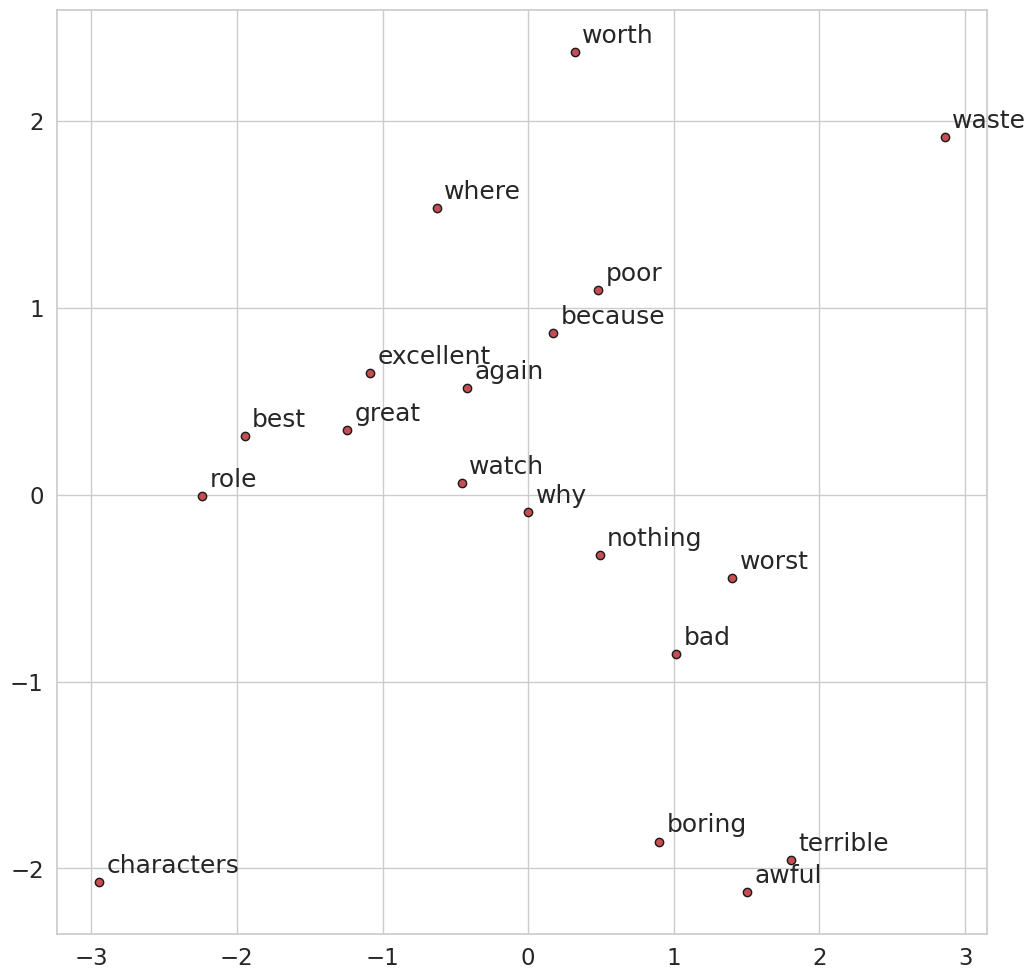

In [43]:
def plot_embeddings_w2v(w2v, words):
    word_vectors = np.array([w2v[a] for a in words])
    # reduce two 2 dimensions
    twodim = PCA(random_state=42).fit_transform(word_vectors)[:,:2]
    plt.figure(figsize=(12,12))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+.05, y+.05, word)
    plt.show()

plot_embeddings_w2v(w2v, ['great', 'best', 'worth', 'again', 'watch', 'excellent', 'characters', 'where', 'role',
                          'worst', 'nothing', 'bad', 'terrible', 'waste', 'boring', 'why', 'awful', 'because', 'poor'])
# seems to be some signal separating words by sentiment.

### Using embeddings for classification

Our first task is to use these embeddings for classification. As mentioned in class, we have a few options for ways of aggregating the vectors for all the words in a document. For example:

1. `average`: average the vectors
2. `max`: take the max along each dimension
3. `min`: take the min along each dimension
4. `min` $\oplus$ `max`: concatenate `min` and `max` vectors (total length = 50*2)

We'll reclassify the movie review data from the previous assignment using word vectors to see if it makes a difference in accuracy.

In [44]:
def average_vectors(words, w2v):
    # stack the vectors (one row per word) and average down the rows
    vecs = np.array([w2v[w] for w in words])
    return vecs.mean(axis=0)

average_vectors(['great', 'wonderful'], w2v)

array([ 1.04381502e-01,  1.12444997e+00, -1.11439991e+00, -1.83170259e-01,
        9.02209997e-01, -1.15970001e-01, -4.11805004e-01,  1.08799994e-01,
       -1.49732307e-01,  4.88041997e-01, -3.08196008e-01,  7.14240015e-01,
        7.25699961e-02, -3.05836499e-01,  3.61425489e-01, -2.32325003e-01,
        8.04440022e-01,  5.78559995e-01, -5.50194502e-01, -4.66484994e-01,
       -2.54790008e-01,  5.64771473e-01, -3.36724997e-01, -2.48538494e-01,
        1.35455000e+00, -1.14691496e+00, -1.47009993e+00,  3.87299955e-02,
        7.62910008e-01, -1.75379992e-01,  2.61150002e+00,  5.92914999e-01,
        1.46920502e-01, -9.90229994e-02,  1.34599954e-03,  3.83454978e-01,
       -2.68949986e-01,  5.49224973e-01, -7.21860006e-02, -2.64769018e-01,
        2.64299959e-02,  1.97219014e-01, -4.18669999e-01, -3.80999967e-02,
       -1.36449933e-02,  6.19724989e-01, -1.01674005e-01, -3.29100013e-01,
       -2.20425010e-01,  2.95679986e-01], dtype=float32)

In [45]:
assert round(average_vectors(['great', 'wonderful'], w2v)[0].item(), 2) == .10
assert round(average_vectors(['great', 'wonderful'], w2v)[1].item(), 2) == 1.12
assert average_vectors(['great', 'wonderful'], w2v).shape[0] == 50

In [46]:
def max_vectors(words, w2v):
    vecs = np.array([w2v[w] for w in words])
    return vecs.max(axis=0)

max_vectors(['great', 'wonderful'], w2v)

array([ 2.3533e-01,  1.3357e+00, -1.0280e+00,  6.5595e-03,  1.2843e+00,
       -1.0495e-01, -3.5433e-01,  3.7824e-01, -2.3046e-03,  8.8219e-01,
       -3.4122e-02,  9.2961e-01,  2.8537e-01,  2.1317e-02,  7.0205e-01,
       -2.1533e-01,  9.6923e-01,  6.8058e-01, -9.6489e-02, -2.4013e-01,
       -1.4633e-01,  1.1343e+00, -1.5865e-01, -3.4477e-02,  1.4644e+00,
       -4.6223e-01, -1.3821e+00,  4.5211e-01,  9.9220e-01,  2.0883e-01,
        3.2209e+00,  6.4549e-01,  3.7438e-01, -2.1476e-02,  2.6856e-02,
        4.2905e-01, -1.1890e-01,  6.9764e-01, -2.9882e-02,  5.1232e-02,
        2.0491e-01,  2.9855e-01, -3.9682e-01,  1.1089e-01,  2.1904e-01,
        6.6251e-01,  6.6142e-02, -1.6162e-01, -2.4670e-02,  8.4626e-01],
      dtype=float32)

In [47]:
assert round(max_vectors(['great', 'wonderful'], w2v)[0].item(), 2) == .24
assert round(max_vectors(['great', 'wonderful'], w2v)[1].item(), 2) == 1.34
assert max_vectors(['great', 'wonderful'], w2v).shape[0] == 50

In [48]:
def min_vectors(words, w2v):
    vecs = np.array([w2v[w] for w in words])
    return vecs.min(axis=0)

min_vectors(['great', 'wonderful'], w2v)

array([-0.026567,  0.9132  , -1.2008  , -0.3729  ,  0.52012 , -0.12699 ,
       -0.46928 , -0.16064 , -0.29716 ,  0.093894, -0.58227 ,  0.49887 ,
       -0.14023 , -0.63299 ,  0.020801, -0.24932 ,  0.63965 ,  0.47654 ,
       -1.0039  , -0.69284 , -0.36325 , -0.004757, -0.5148  , -0.4626  ,
        1.2447  , -1.8316  , -1.5581  , -0.37465 ,  0.53362 , -0.55959 ,
        2.0021  ,  0.54034 , -0.080539, -0.17657 , -0.024164,  0.33786 ,
       -0.419   ,  0.40081 , -0.11449 , -0.58077 , -0.15205 ,  0.095888,
       -0.44052 , -0.18709 , -0.24633 ,  0.57694 , -0.26949 , -0.49658 ,
       -0.41618 , -0.2549  ], dtype=float32)

In [49]:
assert round(min_vectors(['great', 'wonderful'], w2v)[0].item(), 2) == -.03
assert round(min_vectors(['great', 'wonderful'], w2v)[1].item(), 2) == .91
assert min_vectors(['great', 'wonderful'], w2v).shape[0] == 50

In [50]:
def min_max_vectors(words, w2v):
    # min goes first, the test checks index 0 against the min value
    return np.concatenate([min_vectors(words, w2v), max_vectors(words, w2v)])

min_max_vectors(['great', 'wonderful'], w2v)

array([-2.6567e-02,  9.1320e-01, -1.2008e+00, -3.7290e-01,  5.2012e-01,
       -1.2699e-01, -4.6928e-01, -1.6064e-01, -2.9716e-01,  9.3894e-02,
       -5.8227e-01,  4.9887e-01, -1.4023e-01, -6.3299e-01,  2.0801e-02,
       -2.4932e-01,  6.3965e-01,  4.7654e-01, -1.0039e+00, -6.9284e-01,
       -3.6325e-01, -4.7570e-03, -5.1480e-01, -4.6260e-01,  1.2447e+00,
       -1.8316e+00, -1.5581e+00, -3.7465e-01,  5.3362e-01, -5.5959e-01,
        2.0021e+00,  5.4034e-01, -8.0539e-02, -1.7657e-01, -2.4164e-02,
        3.3786e-01, -4.1900e-01,  4.0081e-01, -1.1449e-01, -5.8077e-01,
       -1.5205e-01,  9.5888e-02, -4.4052e-01, -1.8709e-01, -2.4633e-01,
        5.7694e-01, -2.6949e-01, -4.9658e-01, -4.1618e-01, -2.5490e-01,
        2.3533e-01,  1.3357e+00, -1.0280e+00,  6.5595e-03,  1.2843e+00,
       -1.0495e-01, -3.5433e-01,  3.7824e-01, -2.3046e-03,  8.8219e-01,
       -3.4122e-02,  9.2961e-01,  2.8537e-01,  2.1317e-02,  7.0205e-01,
       -2.1533e-01,  9.6923e-01,  6.8058e-01, -9.6489e-02, -2.40

In [51]:
assert round(min_max_vectors(['great', 'wonderful'], w2v)[0].item(), 2) == -.03
assert round(min_max_vectors(['great', 'wonderful'], w2v)[1].item(), 2) == .91
assert min_max_vectors(['great', 'wonderful'], w2v).shape[0] == 100

Next, let's read in the movie review data from HW1 and make a bag-of-words feature matrix.

In [52]:
train_df = pd.read_csv('train.tsv', sep='\t')
test_df = pd.read_csv('test.tsv', sep='\t')
train_df.head(5)

,label,text
0,pos,"Here's another movie that should be loaded into a satellite, fired into space and pointed in the..."
1,pos,Cuban Blood is one of those sleeper films that has a lot to say about life in a very traditional...
2,pos,"This is not ""so bad that it is good,"" it is purely good! For those who don't understand why, you..."
3,pos,Both visually and musically stunning. A treat for both the eye and the ear. The quintessential V...
4,pos,'Cry Freedom' is a movie about how far people will go to find the truth.<br /><br />The first ha...


In [53]:
# make bag-of-words feature matrix for train and test, using default tokenization.
# we remove a few terms that are not in the w2v model
vec = CountVectorizer(max_df=100, min_df=4, binary=True,
                      stop_words=['00am', 'hadn', 'parolini', 'virtzer', 'yelli'])
X_train = vec.fit_transform(train_df.text)
X_test = vec.transform(test_df.text)
print('training matrix shape', X_train.shape, 'testing matrix shape', X_test.shape)
y_train = train_df.label
y_test = test_df.label
print('training label distribution', Counter(y_train))
print('testing label distribution', Counter(y_test))
vocab = np.array(vec.get_feature_names_out())

training matrix shape (400, 2069) testing matrix shape (400, 2069)
training label distribution Counter({'pos': 200, 'neg': 200})
testing label distribution Counter({'pos': 200, 'neg': 200})


Next, we'll write a function that takes in a bag-of-words matrix and returns one that uses word vectors.
Note that we'll pass in the type of aggregation function as a variable to this function. A few tips:

- `vocab` is a numpy array containing the unique terms in the vocabulary
- Recall that `X` is a [csr_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_matrix.html). `X[i].indices` will give the indices for words contained in document i. These indices align with the order of terms in `vocab`.
- So, you can iterate over each document, identify the terms in each document, then collect their word vectors and aggregate by using `aggregation_fn`.
- The returned value should be a two-dimensional numpy array, where each row is a document and each column is a dimension of the aggregated word embeddings.

In [54]:
def make_word_vector_features(X, vocab, w2v, aggregation_fn):
    """
    a numpy.ndarray with n rows and d columns, where n is the number of documents
    in X and d is the word vector dimension resulting from aggregation_fn
    """
    # figure out how long the output vector is (50 for most, 100 for min_max)
    dim = len(aggregation_fn([vocab[0]], w2v))
    rows = []
    for i in range(X.shape[0]):
        words = vocab[X[i].indices]
        if len(words) == 0:
            # a review with none of our vocab words, just give it zeros
            rows.append(np.zeros(dim))
        else:
            rows.append(aggregation_fn(words, w2v))
    return np.vstack(rows)

X_train_avg = make_word_vector_features(X_train, vocab, w2v, average_vectors)
X_test_avg = make_word_vector_features(X_test, vocab, w2v, average_vectors)

X_train_avg[0]

array([ 0.21111901,  0.09722339, -0.04589763, -0.19007003,  0.35279754,
        0.13560535, -0.32095036, -0.04145771, -0.16631453,  0.15858246,
       -0.15997647,  0.08090216, -0.27579013,  0.0892407 ,  0.49825364,
        0.04604268,  0.16236088,  0.05402371, -0.33130684, -0.38498965,
       -0.0384452 ,  0.33487058,  0.17044225,  0.08605411,  0.34108123,
       -1.3364186 , -0.46561575,  0.0950053 ,  0.43425396, -0.2784354 ,
        2.662278  ,  0.27640757, -0.12888812, -0.29127663, -0.0231238 ,
        0.12369248, -0.00536566,  0.06990951, -0.13418339, -0.3184511 ,
       -0.16431892,  0.15570076,  0.04516142,  0.13843744,  0.05441125,
        0.06075108, -0.02255548, -0.1530119 , -0.03517219,  0.08741646],
      dtype=float32)

In [55]:
assert round(float(X_train_avg[0][0]), 2) == 0.21
assert round(float(X_train_avg[0][1]), 2) == 0.10

Finally, we'll fit a LogisticRegression classifier on top of these embeddings to get our final predictions.

In [56]:
def test_lr(X_train, y_train, X_test, y_test):
    """
    fit a logistic regression classifier and report
    accuracy on the testing data.
    """
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, train_df.label)
    y_pred_lr = lr.predict(X_test)
    print(classification_report(test_df.label, y_pred_lr))
    return lr

# here is the accuracy on the original bag-of-words representation
test_lr(X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

         neg       0.80      0.78      0.79       200
         pos       0.78      0.81      0.79       200

    accuracy                           0.79       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.79      0.79      0.79       400



LogisticRegression(max_iter=1000)

In [57]:
# loop over all four aggreagation functions and report acccuracy.
for agg_fn in [average_vectors, min_vectors, max_vectors, min_max_vectors]:
    print(agg_fn.__name__)
    X_train_i = make_word_vector_features(X_train, vocab, w2v, agg_fn)
    X_test_i = make_word_vector_features(X_test, vocab, w2v, agg_fn)
    test_lr(X_train_i, y_train, X_test_i, y_test)

average_vectors
              precision    recall  f1-score   support

         neg       0.75      0.74      0.75       200
         pos       0.75      0.76      0.75       200

    accuracy                           0.75       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.75      0.75       400

min_vectors
              precision    recall  f1-score   support

         neg       0.60      0.64      0.62       200
         pos       0.62      0.58      0.60       200

    accuracy                           0.61       400
   macro avg       0.61      0.61      0.61       400
weighted avg       0.61      0.61      0.61       400

max_vectors
              precision    recall  f1-score   support

         neg       0.68      0.66      0.67       200
         pos       0.67      0.69      0.68       200

    accuracy                           0.68       400
   macro avg       0.68      0.68      0.68       400
weighted avg       0.68      0.68 

Oof, that's a lot of work to have worse accuracy than the simple bag-of-words model! Unfortunately, it's not uncommon for this approach to not improve accuracy much for simple document classification tasks. What are possible reasons for this? What could you do to try to find evidence for one of these potential hypotheses? Enter your answer below.

Averaging squashes everything together. A review has a hundred or so words and only a few of them carry the sentiment, so words like waste or excellent get drowned out by all the neutral words around them. That's also why min and max do even worse. They only keep the most extreme value in each dimension and throw the rest away.

And GloVe wasn't trained for this. It learned from Wikipedia and news text, and it puts words close together when they show up in the same contexts. Good and bad show up in almost the same contexts, so their vectors are really similar (cosine similarity around 0.8). For sentiment that's the one difference we actually care about. Bag of words doesn't have this problem because every word gets its own weight. 50 dimensions is also pretty small.

To find evidence for the second idea, I'd check cosine similarity for a bunch of opposite pairs like good and bad or great and terrible. If most of them come out close, that backs it up. For the averaging idea, I'd weight each word by its tf idf score (or keep only words with a strong bag of words coefficient) before averaging and see if accuracy gets closer to the 0.79 from bag of words.


### Intepreting word vector models

In HW1, we could simply look at the top coefficients of the logistic regression model to try to understand what the model has learned. That won't work here, since a large coefficient for "vector dimension 12" doesn't tell us much, since we don't know what dimension 12 means.

There are a number of ways to make sense of this. A simple one is the following:
- Embed each word in the vocabulary.
- Use the classifier to predict the class probabilities for a document containing that single word.
- We can then use these probabilities as a way to identify terms that the classifier thinks correlate with each class.

Let's start by fitting a classifier again using the average embeddings.

In [58]:
X_train_avg = make_word_vector_features(X_train, vocab, w2v, average_vectors)
X_test_avg = make_word_vector_features(X_test, vocab, w2v, average_vectors)
lr = test_lr(X_train_avg, y_train, X_test_avg, y_test)

              precision    recall  f1-score   support

         neg       0.75      0.74      0.75       200
         pos       0.75      0.76      0.75       200

    accuracy                           0.75       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.75      0.75       400



Now, let's embed each word in the vocabulary for later use.

The function below creates a matrix where each row is a word in the vocabulary, and the columns represent its word embedding.

In [59]:
def embed_words(words, w2v):
    return np.vstack([w2v[w] for w in words])

vocab_embedding = embed_words(vocab, w2v)
print(vocab_embedding[0])
vocab_embedding.shape

[ 2.5581e-01  4.7584e-01  1.7321e+00 -5.8802e-01  1.5441e-01 -5.8223e-01
  3.5984e-01 -7.6233e-01  5.9102e-02 -2.4452e-01 -1.2084e-01 -1.1808e+00
  1.3921e+00 -1.0531e+00  1.2464e+00 -1.2706e+00  5.4966e-02  9.2917e-01
 -6.7983e-01  2.7904e-04  2.0821e-01 -2.8121e-01  1.2211e+00  3.6001e-01
 -6.4722e-02  1.0667e+00  3.6614e-01 -1.0744e+00 -4.7448e-01  1.8174e-01
  1.9686e+00  2.1275e-01  3.2139e-01  8.3837e-01 -1.8424e-02  3.9793e-01
  7.0261e-01 -3.2458e-01 -6.5634e-02  2.5243e-01  4.7815e-01 -4.4088e-01
  1.4213e+00 -1.8419e-01 -1.6428e-01  4.3174e-02 -5.3504e-01  1.4311e-01
 -5.2037e-01 -4.1152e-01]


(2069, 50)

We can now classify each word in `vocab_embedding` to get the probability of the a document containing this single word of being in the positive class. You'll have to use the `predict_proba` method of [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [60]:
def get_probability_of_positive_class(vocab_embedding, lr):
    # predict_proba gives one column per class, sorted alphabetically,
    # so column 1 is 'pos'
    return lr.predict_proba(vocab_embedding)[:, 1]

get_probability_of_positive_class(vocab_embedding, lr)

array([6.70570767e-01, 9.07374680e-01, 9.81580218e-01, ...,
       3.33429493e-02, 6.94509574e-04, 6.55149074e-03])

In [62]:
assert round(get_probability_of_positive_class(vocab_embedding, lr)[0], 2) == .68

AssertionError: 

Now, we can print the top words for each class using the above function.

In [63]:
def get_top_words(lr, vocab_embeddings, vocab, topn=10):
    theta = lr.predict_proba(vocab_embedding)[:,1]
    ret = []
    print('positive terms')
    for i in np.argsort(theta)[::-1][:topn]:
        print('%20s\t%.10f' % (vocab[i], theta[i]))
        ret.append(vocab[i])
    print()
    print('negative terms')
    for i in np.argsort(theta)[:topn]:
        print('%20s\t%.10f' % (vocab[i], theta[i]))
        ret.append(vocab[i])
    return ret
top_words = get_top_words(lr, vocab_embedding, vocab, topn=20)

positive terms
        contemporary	0.9999521543
               world	0.9999482582
               music	0.9999479982
           spiritual	0.9999404943
                tour	0.9999233423
               title	0.9999180514
             african	0.9998895224
                 won	0.9998762411
               event	0.9998661944
              spirit	0.9998479773
               games	0.9998336073
             classic	0.9998304441
           adventure	0.9998196606
            festival	0.9998164872
              unique	0.9998130926
                 art	0.9998035373
            classics	0.9997869496
            showcase	0.9997868256
             musical	0.9997801338
                star	0.9997801065

negative terms
             rubbish	0.0000006737
             garbage	0.0000015234
               trash	0.0000047129
               waste	0.0000054228
              rotten	0.0000055691
              sucked	0.0000078815
                mess	0.0000110673
               dirty	0.0000158363
                 

Looking back at HW1 and the top terms we found with logistic regression, how do these top terms compare? Does one look better or worse? Why?

The negative side looks really good. Rubbish, garbage, trash, waste, sucked, crap, unfunny. All of those are clearly negative, and a few of them barely show up in the reviews at all. That's the nice part about embeddings. A rare word still gets a decent score if its vector sits close to words the model saw a lot. HW1 had a solid negative list too, with worst, nothing, bad, terrible, waste, boring, awful and poor. So that side is about even. Both lists have some random words mixed in. HW1 had why, because, being and the number 1, and this one has jaw, skin and mouth.

The positive side is where they split. Contemporary, world, music, spiritual, african, festival, tour. None of those are opinions. They're topics. I think a lot of the positive reviews in this dataset are about festival films, foreign films and music docs, so the classifier learned that part of the space means positive. HW1 had real opinion words up top like great, best, worth and excellent, even if characters, himself and man snuck in too. So HW1 looks better to me overall. The embedding model picks up on what a review is about, not on how the person felt about the movie.


<br><br><br><br><br>

## Part II: Sequence Models

Next, we'll turn to HMMs and RNNs for the task of part-of-speech tagging.

Here is a simple class to store the main data structures we'll need.

In [64]:
class HMM:
    def __init__(self, states, vocab, smoothing=0):
        self.states = states
        self.vocab = vocab
        self.smoothing = smoothing
        # we'll set these below.
        self.transition_probas = None
        self.emission_probas = None
        self.start_probas = None

Assume we have some training data of sentences and their corresponding part-of-speech tags:


In [65]:
sentences_small = [
                    ['the', 'boy', 'jumped'],
                    ['the', 'dog', 'jumped'],
                    ['jump', 'dog'],
                    ['the', 'ball', 'boy', 'ran']
                  ]

tags_small = [
                ['D', 'N', 'V'],
                ['D', 'N', 'V'],
                ['V', 'N'],
                ['D', 'N', 'N', 'V']
            ]

states_small = ['D', 'N', 'V']
vocab_small =['ball', 'boy', 'dog', 'jump', 'jumped', 'ran', 'the']

### transition probabilities

First, let's implement a function to fit the transition probabilities. We'll use the add-$k$ smoothed estimates from [lecture](http://cs.tulane.edu/~aculotta/nlp/sequence/hmm2.html). To store the probabilities, we'll use a "dict of dicts", like:

```
{'D': {'D': 0.0, 'N': 1.0, 'V': 0.0},
 'N': {'D': 0.0, 'N': 0.25, 'V': 0.75},
 'V': {'D': 0.0, 'N': 1.0, 'V': 0.0}}
```

In this example, the probability of a transition from `N->V` is 0.75.

Complete the function below and test your implementation. Note that transitions should appear in the result even if they are not seen in the training data. E.g., above there is a 0 probability transition from D->D. When smoothing is used, this will be non-zero.

(If your object-oriented design aesthetics are offended that `fit_transition_probas` is not a method of the HMM class, then they are well-tuned. We are doing it this way solely for ease of testing.)

In [66]:
def fit_transition_probas(hmm, tags):
    """
    Given an HMM and a dataset, return the transition probabilities between each pair of states.

    Params:
      hmm.....an HMM
      tags....a list of list of strings representing the POS tags for a list of sentences.
    """
    k = hmm.smoothing
    n_states = len(hmm.states)
    # counts[prev][next] = how many times prev was followed by next
    counts = {s: Counter() for s in hmm.states}
    for tag_list in tags:
        for prev, nxt in zip(tag_list[:-1], tag_list[1:]):
            counts[prev][nxt] += 1

    probas = {}
    for prev in hmm.states:
        total = sum(counts[prev].values())
        denom = total + k * n_states
        probas[prev] = {}
        for nxt in hmm.states:
            # add-k smoothing, (count + k) / (total + k * N)
            probas[prev][nxt] = (counts[prev][nxt] + k) / denom if denom > 0 else 0.0
    return probas


In [67]:
hmm = HMM(states_small, vocab_small, smoothing=0)
hmm.transition_probas = fit_transition_probas(hmm, tags_small)
assert 0.750 == round(hmm.transition_probas['N']['V'], 3)
assert 0.0 == round(hmm.transition_probas['N']['D'], 1)
assert 0.250 == round(hmm.transition_probas['N']['N'], 3)

display(dict(hmm.transition_probas))

{'D': {'D': 0.0, 'N': 1.0, 'V': 0.0},
 'N': {'D': 0.0, 'N': 0.25, 'V': 0.75},
 'V': {'D': 0.0, 'N': 1.0, 'V': 0.0}}

In [68]:
hmm = HMM(states_small, vocab_small, smoothing=1)
hmm.transition_probas = fit_transition_probas(hmm, tags_small)
assert 0.571 == round(hmm.transition_probas['N']['V'], 3)
assert 0.143 == round(hmm.transition_probas['N']['D'], 3)
assert 0.286 == round(hmm.transition_probas['N']['N'], 3)

### emission probabilities

Next, let's fit the emission probabilities.

In [69]:
def fit_emission_probas(hmm, sentences, tags):
    k = hmm.smoothing
    V = len(hmm.vocab)
    counts = {s: Counter() for s in hmm.states}
    for sentence, tag_list in zip(sentences, tags):
        for word, tag in zip(sentence, tag_list):
            counts[tag][word] += 1

    probas = {}
    for state in hmm.states:
        total = sum(counts[state].values())
        denom = total + k * V
        probas[state] = {}
        for word in hmm.vocab:
            probas[state][word] = (counts[state][word] + k) / denom if denom > 0 else 0.0
    return probas


In [70]:
hmm = HMM(states_small, vocab_small, smoothing=0)
hmm.emission_probas = fit_emission_probas(hmm, sentences_small, tags_small)
assert 0.2 == round(hmm.emission_probas['N']['ball'], 1)
assert 0.4 == round(hmm.emission_probas['N']['boy'], 1)
assert 0.4 == round(hmm.emission_probas['N']['dog'], 1)
assert 0.0 == round(hmm.emission_probas['N']['jump'], 1)
assert 0.0 == round(hmm.emission_probas['N']['ran'], 1)

In [71]:
hmm = HMM(states_small, vocab_small, smoothing=1)
hmm.emission_probas = fit_emission_probas(hmm, sentences_small, tags_small)
assert 0.4 == round(hmm.emission_probas['D']['the'], 1)
assert 0.1 == round(hmm.emission_probas['D']['ball'], 1)
assert 0.1 == round(hmm.emission_probas['D']['boy'], 1)
assert 0.1 == round(hmm.emission_probas['D']['jump'], 1)

### start probabilities

The final probabilities we need to estimate is the start probabilities. That is, what is the probability of a tag starting a sentence? (For this assignment, we'll ignore end states.)

In [72]:
def fit_start_probas(hmm, tags):
    k = hmm.smoothing
    counts = Counter(tag_list[0] for tag_list in tags if len(tag_list) > 0)
    total = sum(counts.values())
    denom = total + k * len(hmm.states)
    return {s: (counts[s] + k) / denom for s in hmm.states}


In [73]:
hmm = HMM(states_small, vocab_small, smoothing=0)
hmm.start_probas = fit_start_probas(hmm, tags_small)
assert 0.75 == round(hmm.start_probas['D'], 2)
assert 0.0 == round(hmm.start_probas['N'], 1)
assert 0.25 == round(hmm.start_probas['V'], 2)

### Viterbi

Now that we can estimate all the HMM parameters, we'll implement Viterbi search.

This function will return both the most probable state sequence as well as its probability.

See the book for more details. One issue is keeping track of which state was chosen at each step. You can do this with a "backpointer" matrix to keep track of the best edges. This is a 2d array just like the lattice used by Viterbi. Cell (i,j) stores for state i at time step j the best preceding state at time j-1. That is, it indicates which edge was taken to reach state i at time j. (See [Figure A.10](https://github.com/tulane-cmps6730/main/blob/main/read/slpA.pdf) from the book.)


In [74]:
def _log(p):
    # log(0) blows up, so treat it as -inf instead
    return math.log(p) if p > 0 else float('-inf')


def viterbi(hmm, sentence):
    """
    Perform Viterbi search to identify the most probable set of hidden states for
    the provided input sentence.

    Be sure that the runtime of your implementation is O(N^2 * T), where N is
    the number of states and T is the number of sentence tokens.

    Params:
      sentence...a lists of strings, representing the tokens in a single sentence.

    Returns:
      path....a list of strings indicating the most probable path of POS tags for
              this sentence.
      proba...a float indicating the probability of this path.
    """
    states = hmm.states
    T = len(sentence)

    # I work in log space so long sentences don't underflow to 0.
    # lattice[t][s] = best log prob of any path that ends in state s at time t
    # backpointer[t][s] = the state at t-1 that got us there
    lattice = [{} for _ in range(T)]
    backpointer = [{} for _ in range(T)]

    # first word, start prob times emission
    for s in states:
        emit = hmm.emission_probas[s].get(sentence[0], 0.0)
        lattice[0][s] = _log(hmm.start_probas[s]) + _log(emit)
        backpointer[0][s] = None

    # every other word. two loops over states inside a loop over words,
    # that's the O(N^2 * T)
    for t in range(1, T):
        word = sentence[t]
        for s in states:
            emit = _log(hmm.emission_probas[s].get(word, 0.0))
            best_prev, best_score = None, float('-inf')
            for prev in states:
                score = lattice[t - 1][prev] + _log(hmm.transition_probas[prev][s])
                if best_prev is None or score > best_score:
                    best_prev, best_score = prev, score
            lattice[t][s] = best_score + emit
            backpointer[t][s] = best_prev

    # pick the best last state, then walk the backpointers backwards
    last = max(states, key=lambda s: lattice[T - 1][s])
    best_log = lattice[T - 1][last]
    path = [last]
    for t in range(T - 1, 0, -1):
        path.append(backpointer[t][path[-1]])
    path.reverse()

    proba = math.exp(best_log) if best_log > float('-inf') else 0.0
    return path, proba


In [75]:
"""
To test our implementation, we'll consider the sentence "time flies like an arrow".
There is ambiguity in the word "flies", which could be a noun or verb, as well
as the word "like," which could be a preposition or a verb.
"""
hmm = HMM(states=['D', 'N', 'P', 'V'],
          vocab=['an', 'arrow', 'flies', 'like', 'time'],
          smoothing=0)

hmm.start_probas = {
                    'D': .3,
                    'N': .4,
                    'P': .1,
                    'V': .2,
                   }

hmm.emission_probas = {
                         'D': {'time': 0.0, 'flies': 0.0, 'like': 0.0, 'an': 1.0, 'arrow': 0.0},
                         'V': {'time': 0.0, 'flies': 0.5, 'like': 0.5, 'an': 0.0, 'arrow': 0.0},
                         'P': {'time': 0.0, 'flies': 0.0, 'like': 1.0, 'an': 0.0, 'arrow': 0.0},
                         'N': {'time': 0.3, 'flies': 0.3, 'like': 0.0, 'an': 0.0, 'arrow': 0.4}
                      }
hmm.transition_probas = {
                           'D': {'D': 0.0, 'N': 1.0, 'P': 0.0, 'V': 0.0},
                           'N': {'D': 0.0, 'N': 0.3, 'P': 0.2, 'V': 0.5},
                           'P': {'D': 0.8, 'N': 0.2, 'P': 0.0, 'V': 0.0},
                           'V': {'D': 0.2, 'N': 0.5, 'P': 0.3, 'V': 0.0}
                        }

path, proba = viterbi(hmm, ['time', 'flies', 'like', 'an', 'arrow'])
assert list(path) ==  ['N', 'V', 'P', 'D', 'N']
assert .003 == round(proba, 3)

Sometimes we want to find the second most probable output path for an input sentence. In the cell below, describe in words an algorithm to find the second most probable path. What is its Big-Oh runtime?

Run Viterbi like normal, but keep the two best scores in every cell instead of just one. So for each state at each time step we store the best way and the second best way to get there, and each one gets its own backpointer. The backpointer has to remember which previous state we came from and also which of that state's two entries.

To fill a cell we look at every previous state and both of its entries, so 2N options, and we keep the top two. At the end we look at all the final cells, take the second highest score overall, and follow its backpointers back to get the path.

Runtime is O(2 N^2 T), which is still O(N^2 T) since the 2 is a constant. If we wanted the k best paths it would be O(k N^2 T).


### running your HMM on real data

Now that your HMM is working, we'll apply it to some real data. The file `pos.txt` contains sentences from news articles that have been annotated with their parts-of-speech. A list of part-of-speech tag definitions can be found [here](https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html).

In [78]:
def read_labeled_data(filename):
    sentences = []
    tags = []
    cur_sentence = []
    cur_tags = []
    for line in open(filename):
        parts = line.split()
        if len(parts) < 2: # next sentence
            sentences.append(cur_sentence)
            tags.append(cur_tags)
            cur_sentence = []
            cur_tags = []
        else:
            cur_sentence.append(parts[0])
            cur_tags.append(parts[1])
    return sentences, tags
sentences, tags = read_labeled_data('pos.txt')
print('read %d sentences containing %d tokens' % (len(sentences), sum(len(s) for s in sentences)))

read 84 sentences containing 1894 tokens


In [79]:
# find the unique set of states
states = set()
for tag_list in tags:
    states.update(tag_list)
states = sorted(list(states))
print('%d unique states' % len(states))

# find the vocabulary
vocab = set()
for sentence in sentences:
    vocab.update(sentence)
vocab = sorted(list(vocab))
print('%d unique words' % len(vocab))

34 unique states
716 unique words


In [80]:
train_sentences, test_sentences = sentences[:-10], sentences[-10:]
train_tags, test_tags = tags[:-10], tags[-10:]

hmm = HMM(states=states, vocab=vocab, smoothing=0.001)
hmm.start_probas = fit_start_probas(hmm, train_tags)
hmm.transition_probas = fit_transition_probas(hmm, train_tags)
hmm.emission_probas = fit_emission_probas(hmm, train_sentences, train_tags)
sentence = ['Look', 'at', 'what', 'happened']
print('predicted parts of speech for the sentence %s' % str(sentence))
path, proba = viterbi(hmm, sentence)
print(path, proba)
assert path == ['VB', 'IN', 'WP', 'VBD']

predicted parts of speech for the sentence ['Look', 'at', 'what', 'happened']
['VB', 'IN', 'WP', 'VBD'] 4.964473162939984e-10


There are many ways to evaluate accuracy of an HMM. A simple way is to compute the accuracy averaged over all tokens.

In [81]:
def evaluate(hmm, sentences, tags):
    truths = []
    preds = []
    for sentence, tag_list in zip(sentences, tags):
        path, proba = viterbi(hmm, sentence)
        truths.extend(tag_list)
        preds.extend(path)
    print(classification_report(truths, preds, zero_division=0))

evaluate(hmm, test_sentences, test_tags)

              precision    recall  f1-score   support

           $       0.70      1.00      0.82         7
           ,       0.93      1.00      0.96        13
           .       0.83      1.00      0.91        10
           :       0.00      0.00      0.00         0
          CC       1.00      1.00      1.00         8
          CD       0.80      0.75      0.77        16
          DT       0.93      1.00      0.96        13
          EX       0.00      0.00      0.00         0
          IN       0.93      0.93      0.93        29
          JJ       0.75      0.60      0.67        15
         JJR       0.17      0.33      0.22         3
         JJS       0.00      0.00      0.00         0
          MD       0.00      0.00      0.00         0
          NN       0.88      0.58      0.70        36
         NNP       0.92      0.38      0.54        29
        NNPS       0.00      0.00      0.00         1
         NNS       0.94      0.63      0.76        27
         POS       0.67    

What will happen if the HMM encounters a word that is not in `vocab`?  How could you fix this?

The emission table only has words from vocab. If we index it directly we get a KeyError and the whole thing crashes. In here I used .get, so an unknown word just gets probability 0 for every tag. That doesn't crash, but it's still bad. Every path through that word has probability 0, so Viterbi can't tell the tags apart and just picks the first one. And since everything gets multiplied together, one unknown word wipes out the probability of the whole sentence.

We can see a softer version of this here. The test words are in vocab, but a lot of them never showed up in training, so all they get is the tiny smoothing probability. That's a big part of why test accuracy is only around 0.71.

The fix is an UNK token. In training, replace words that only show up once with UNK, so the model learns which tags rare words usually get (mostly NN and NNP). At test time any word we haven't seen becomes UNK. It works even better if we have a few UNK types based on what the word looks like, like capitalized, ends in ing, ends in ed, or has a digit. Those give the tagger real hints about the tag.


## Part III: RNNs for POS tagging

Finally, we'll apply RNNs to this task. Below is a slightly modified version of the RNN we introduced in lecture.

We'll first train it using the `small` dataset.

In [82]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, states, verbose=True):
        super(RNN, self).__init__()
        self.states = states
        self.verbose = verbose
        self.n_hidden = hidden_size
        # W_xh
        self.input_to_hidden = nn.Linear(input_size, hidden_size)
        # W_hh
        self.hidden_to_hidden = nn.Linear(hidden_size, hidden_size)
        # W_hy
        self.hidden_to_output = nn.Linear(hidden_size, output_size)
        self.tanh = nn.Tanh()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x, h_prev):
        # tanh(𝑊_hh h_t-1 + W_xh x_t)
        h_new = self.tanh(self.hidden_to_hidden(h_prev) + self.input_to_hidden(x))
        # y_h = softmax(W_hy h)
        output = self.softmax(self.hidden_to_output(h_new))

        if self.verbose: print('h_new\n', h_new, '\noutput\n',output, '\ntop output\n', output2label(output, self.states))
        return output, h_new

    def forward_unrolled(self, x_list):
        """
        Given a character list, unroll the network and gather
        predictions for each time step.
        """
        hidden = torch.zeros(1, self.n_hidden)
        outputs = []
        hiddens = []
        for x in x_list:
            output, hidden = self.forward(x, hidden)
            outputs.append(output)
            hiddens.append(hidden)
        return torch.cat(outputs), hidden

def output2label(output, states):
    """
    return the letter for the most probable prediction
    """
    top_n, top_i = output.topk(1)
    return states[top_i.item()] # , math.exp(top_n)


def one_hot(vocab, word):
    x = torch.zeros((1, len(vocab)))
    x[0][vocab.index(word)] = 1.0
    return x

def one_hots(vocab, words):
    return torch.cat([one_hot(vocab, w) for w in words])

torch.random.manual_seed(42)
rnn = RNN(len(vocab_small), 2, len(states_small), states_small)

In [83]:
# here's a prediction for one sentence, with random weights
outputs, hiddens = rnn.forward_unrolled(one_hots(vocab_small, ['the', 'boy', 'jumped']))

h_new
 tensor([[-0.3163, -0.0849]], grad_fn=<TanhBackward0>) 
output
 tensor([[0.2940, 0.1594, 0.5466]], grad_fn=<SoftmaxBackward0>) 
top output
 V
h_new
 tensor([[-0.0111,  0.2785]], grad_fn=<TanhBackward0>) 
output
 tensor([[0.3631, 0.1358, 0.5010]], grad_fn=<SoftmaxBackward0>) 
top output
 V
h_new
 tensor([[-0.2006, -0.0117]], grad_fn=<TanhBackward0>) 
output
 tensor([[0.3072, 0.1523, 0.5404]], grad_fn=<SoftmaxBackward0>) 
top output
 V


In [84]:
# we'll have to one-hot-encode both the input words and output states to create the data.
rnn_data_small = [(one_hots(vocab_small, sentence), one_hots(states_small, tag_list))
                    for sentence, tag_list in zip(sentences_small, tags_small)]
rnn_data_small[0]

(tensor([[0., 0., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0.]]),
 tensor([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]))

100%|██████████| 10/10 [00:00<00:00, 60.69it/s]


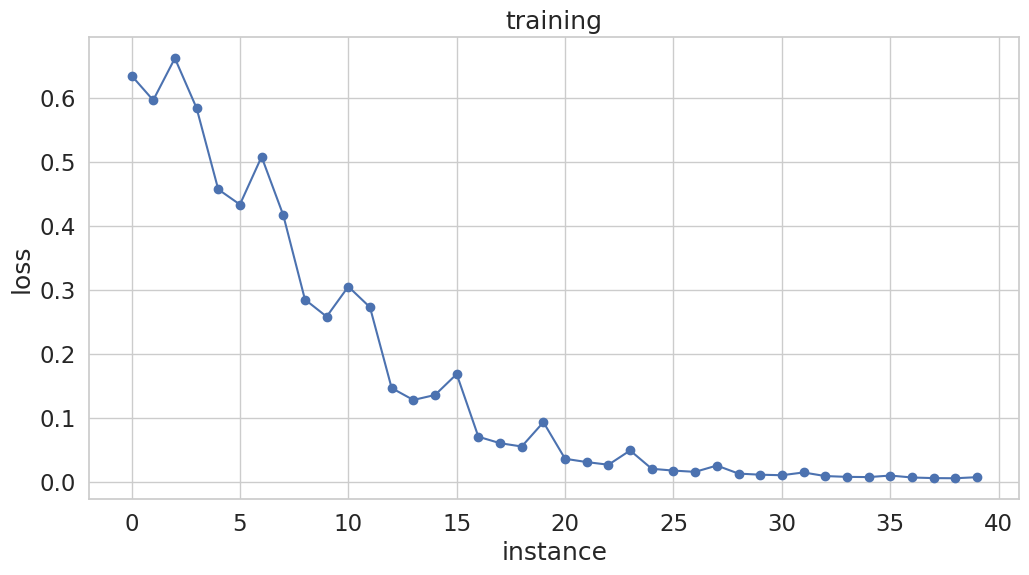

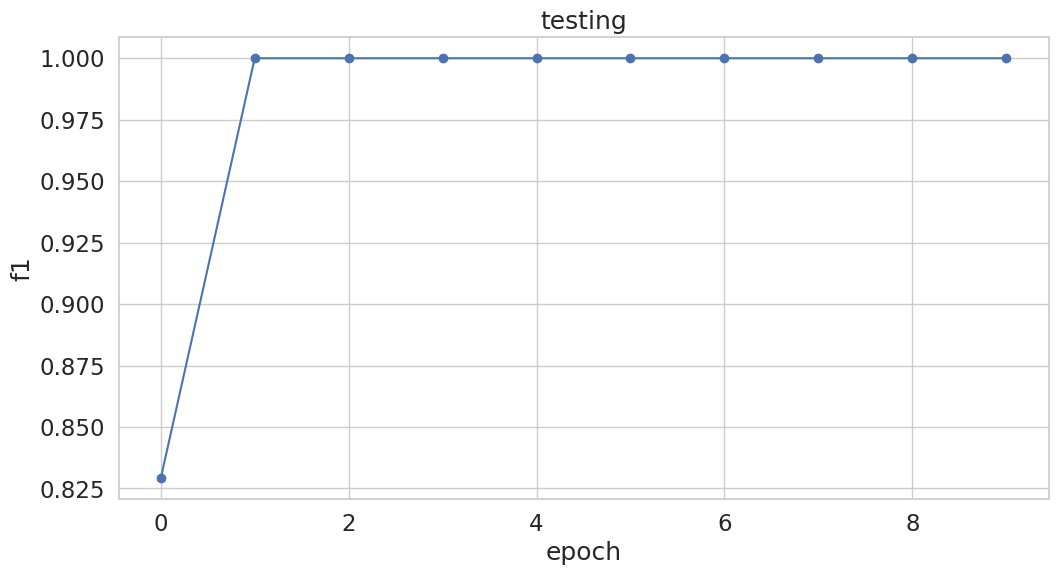

RNN(
  (input_to_hidden): Linear(in_features=7, out_features=2, bias=True)
  (hidden_to_hidden): Linear(in_features=2, out_features=2, bias=True)
  (hidden_to_output): Linear(in_features=2, out_features=3, bias=True)
  (tanh): Tanh()
  (softmax): Softmax(dim=1)
)

In [85]:
def train_rnn(rnn, train_data, test_data, epochs=20, learning_rate=0.1):
    torch.random.manual_seed(42)  # for reproducibility
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(rnn.parameters(),
                                 lr=learning_rate)
    rnn.verbose = False
    loss_val = []
    test_acc = []
    # main training loop
    # here, we're updating after each sentence.
    # to improve convergence, we should really use mini-batches (e.g., a group of ~20 sentences)
    # but, this is a bit easier.
    for epoch in tqdm(range(epochs), total=epochs):
        for sentence, tags in train_data:
            optimizer.zero_grad()                             # reset all the gradient information
            outputs, hiddens = rnn.forward_unrolled(sentence) # predict on this sentence
            loss = criterion(outputs, tags)                   # compute loss
            loss.backward()                                   # computes all the gradients
            optimizer.step()                                  # update parameters
            loss_val.append(loss.item())                      # track loss on each sentence
        # after each epoch, record the test accuracy.
        test_acc.append(evaluate_rnn(rnn, test_data, verbose=False))

    # plot training loss
    plt.figure()
    plt.plot(loss_val, 'bo-')
    plt.ylabel('loss')
    plt.xlabel('instance')
    plt.title('training')
    plt.show()
    # plot testing F1
    plt.figure()
    plt.plot(test_acc, 'bo-')
    plt.ylabel('f1')
    plt.xlabel('epoch')
    plt.title('testing')
    plt.show()

    return rnn


def evaluate_rnn(rnn, data, verbose=True):
    rnn.verbose = False
    truths = []
    preds = []
    for sentence, tag_list in data:
        outputs, _ = rnn.forward_unrolled(sentence)
        pred = [output2label(output, rnn.states) for output in outputs]
        truth = [output2label(tag, rnn.states) for tag in tag_list]
        truths.extend(truth)
        preds.extend(pred)
    if verbose:
        print(classification_report(truths, preds, zero_division=0))
    return f1_score(truths, preds, average='weighted')

rnn = RNN(len(vocab_small), 2, len(states_small), states_small)
train_rnn(rnn, rnn_data_small, rnn_data_small, epochs=10)

The RNN seems to have no problem fitting this tiny dataset.

In [86]:
# here's one prediction of the trained RNN
rnn.verbose=True
_, _ = rnn.forward_unrolled(one_hots(vocab_small, ['the', 'boy', 'jumped']))

h_new
 tensor([[0.9846, 0.9784]], grad_fn=<TanhBackward0>) 
output
 tensor([[0.9866, 0.0082, 0.0053]], grad_fn=<SoftmaxBackward0>) 
top output
 D
h_new
 tensor([[ 0.6585, -0.9980]], grad_fn=<TanhBackward0>) 
output
 tensor([[4.6534e-03, 9.9509e-01, 2.5693e-04]], grad_fn=<SoftmaxBackward0>) 
top output
 N
h_new
 tensor([[-0.9099,  0.9711]], grad_fn=<TanhBackward0>) 
output
 tensor([[0.0046, 0.0027, 0.9927]], grad_fn=<SoftmaxBackward0>) 
top output
 V


### RNNs on real data.

Next, we'll try the larger dataset.

In [87]:
# one-hot-encode the larger POS dataset
rnn_data = [(one_hots(vocab, sentence), one_hots(states, tag_list))
            for sentence, tag_list in zip(sentences, tags)]
rnn_data_train, rnn_data_test = rnn_data[:-10], rnn_data[-10:]
print('%d training and %d testing sentences' % (len(rnn_data_train), len(rnn_data_test)))

74 training and 10 testing sentences


100%|██████████| 15/15 [00:08<00:00,  1.87it/s]


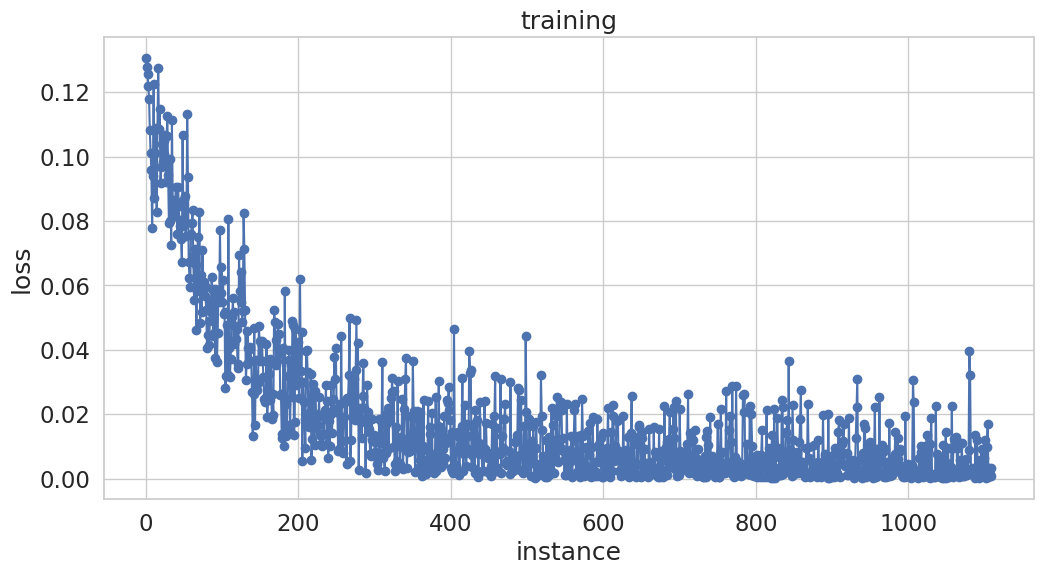

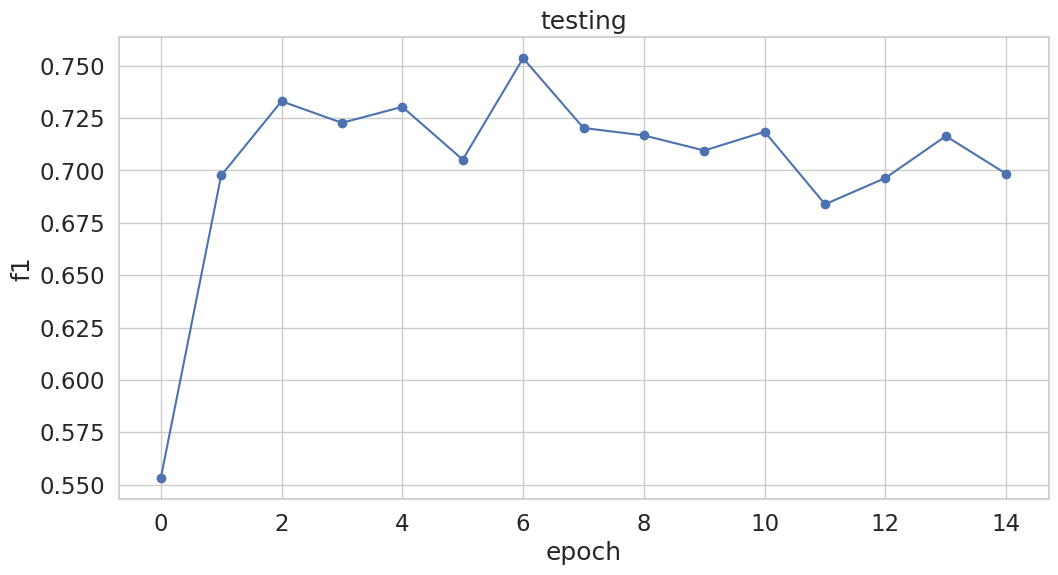

RNN(
  (input_to_hidden): Linear(in_features=716, out_features=5, bias=True)
  (hidden_to_hidden): Linear(in_features=5, out_features=5, bias=True)
  (hidden_to_output): Linear(in_features=5, out_features=34, bias=True)
  (tanh): Tanh()
  (softmax): Softmax(dim=1)
)

In [88]:
rnn = RNN(len(vocab), 5, len(states), states)
train_rnn(rnn, rnn_data_train, rnn_data_test, epochs=15)

In [89]:
# predict on one example.
rnn.verbose=True
_, _ = rnn.forward_unrolled(one_hots(vocab, ['Look', 'at', 'what', 'happened']))

h_new
 tensor([[0.8394, 0.9664, 0.9760, 0.9825, 0.0664]], grad_fn=<TanhBackward0>) 
output
 tensor([[2.8182e-05, 3.1430e-03, 2.6320e-08, 2.6340e-10, 8.7698e-03, 1.5546e-08,
         4.4186e-07, 1.2654e-05, 3.7940e-03, 9.5280e-07, 4.4564e-09, 2.2153e-03,
         8.1422e-03, 6.8422e-04, 1.8661e-07, 3.6826e-08, 3.3677e-05, 1.3451e-07,
         3.9988e-02, 4.6146e-05, 8.8973e-07, 1.9465e-04, 6.6786e-05, 2.4921e-09,
         8.5953e-01, 9.8084e-13, 1.8769e-02, 1.4664e-07, 8.8431e-04, 8.0627e-11,
         2.1485e-04, 1.4155e-03, 1.1878e-02, 4.0192e-02]],
       grad_fn=<SoftmaxBackward0>) 
top output
 VB
h_new
 tensor([[ 0.7849, -0.9975, -0.9908,  0.9975, -0.9960]],
       grad_fn=<TanhBackward0>) 
output
 tensor([[6.5356e-12, 1.4622e-06, 7.4775e-10, 1.8652e-11, 2.9610e-08, 4.6456e-07,
         4.1888e-05, 6.9651e-14, 4.6442e-11, 9.9885e-01, 5.0029e-07, 2.3706e-09,
         4.5826e-08, 2.0813e-12, 1.0558e-09, 3.3817e-05, 6.3331e-07, 9.3985e-14,
         1.8751e-08, 5.2625e-10, 1.7426e-05, 4

In [90]:
evaluate_rnn(rnn, rnn_data_test)

              precision    recall  f1-score   support

           $       1.00      1.00      1.00         7
           ,       1.00      1.00      1.00        13
           .       1.00      1.00      1.00        10
          CC       1.00      1.00      1.00         8
          CD       0.36      0.31      0.33        16
          DT       1.00      1.00      1.00        13
          IN       0.85      0.97      0.90        29
          JJ       1.00      0.47      0.64        15
         JJR       0.50      0.33      0.40         3
          NN       0.48      0.78      0.60        36
         NNP       0.62      0.34      0.44        29
        NNPS       0.00      0.00      0.00         1
         NNS       1.00      0.56      0.71        27
         POS       1.00      1.00      1.00         2
          RB       0.00      0.00      0.00         1
         RBR       1.00      1.00      1.00         1
          TO       1.00      1.00      1.00         6
          VB       0.00    

0.6983925917433598

### RNNs with word embeddings

The RNN seems pretty comparable with the HMM. As usual, more data and more tuning would likely lead to higher accuracy for the RNN.

Next, we can use the word embeddings as the input representation for each word, rather than the one-hot encoding.

In [91]:
# Use mean vector if word not in w2v
MEAN_VEC = w2v.vectors.mean(axis=0)

def embed_words_rnn(w2v, sentence):
    """
    Embed each token with its vector from w2v.
    """
    return torch.tensor([w2v[w.lower()] if w.lower() in w2v else MEAN_VEC for w in sentence])

rnn_data_embed = [(embed_words_rnn(w2v, sentence), one_hots(states, tag_list))
                    for sentence, tag_list in zip(sentences, tags)]
rnn_data_embed_train, rnn_data_embed_test = rnn_data_embed[:-10], rnn_data_embed[-10:]
print('%d training and %d testing sentences' % (len(rnn_data_embed_train), len(rnn_data_embed_test)))

74 training and 10 testing sentences


/tmp/ipykernel_7795/806750809.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor([w2v[w.lower()] if w.lower() in w2v else MEAN_VEC for w in sentence])


100%|██████████| 15/15 [00:08<00:00,  1.78it/s]


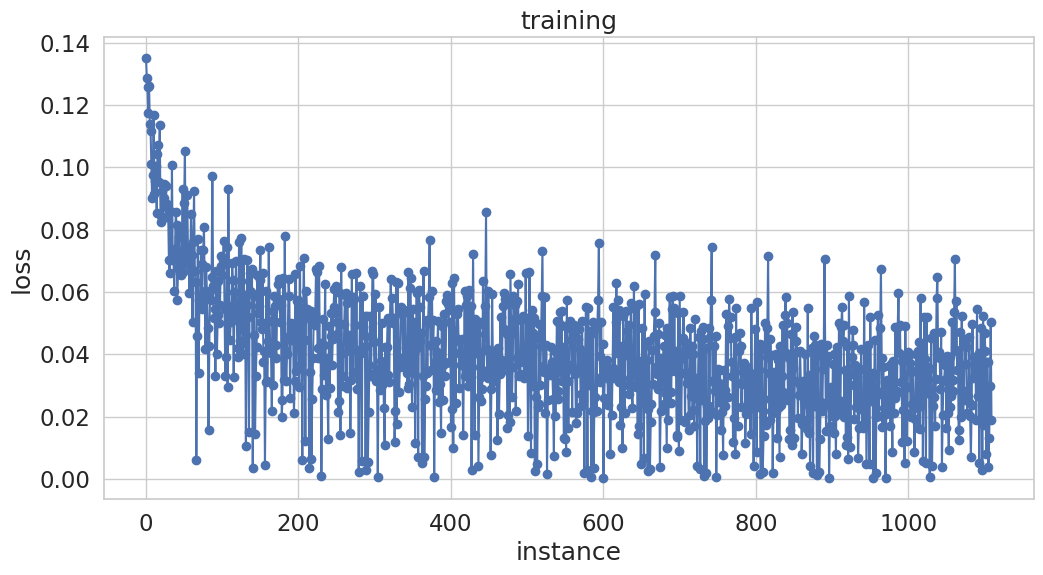

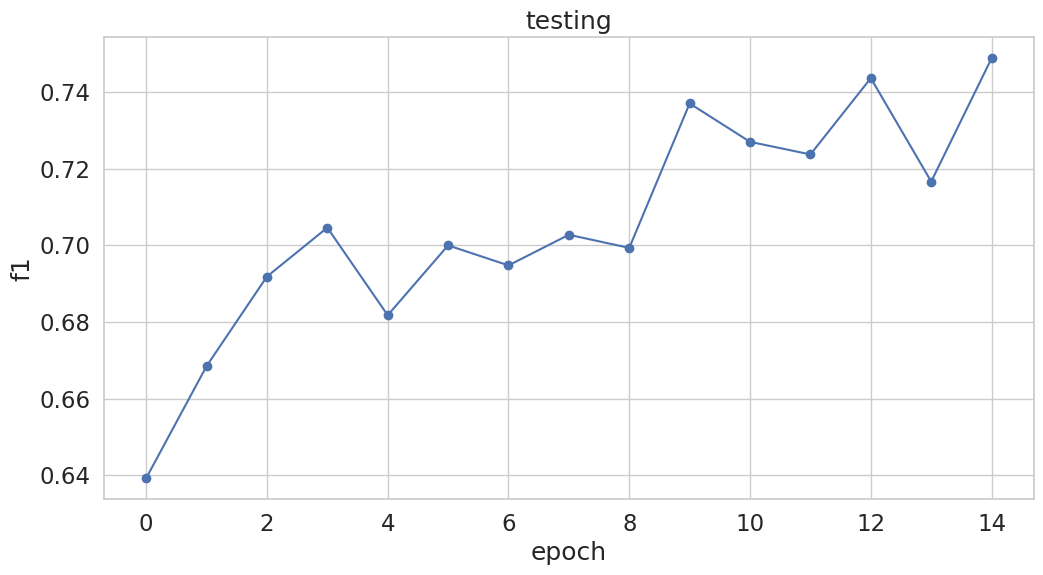

RNN(
  (input_to_hidden): Linear(in_features=50, out_features=10, bias=True)
  (hidden_to_hidden): Linear(in_features=10, out_features=10, bias=True)
  (hidden_to_output): Linear(in_features=10, out_features=34, bias=True)
  (tanh): Tanh()
  (softmax): Softmax(dim=1)
)

In [92]:
# the input dimension has now changed to 50, the size of the word embedding
rnn = RNN(50, 10, len(states), states)
train_rnn(rnn, rnn_data_embed_train, rnn_data_embed_test, epochs=15, learning_rate=.05)

In [93]:
evaluate_rnn(rnn, rnn_data_embed_test)

              precision    recall  f1-score   support

           $       1.00      1.00      1.00         7
           ,       1.00      1.00      1.00        13
           .       0.77      1.00      0.87        10
          CC       0.89      1.00      0.94         8
          CD       1.00      0.88      0.93        16
          DT       1.00      1.00      1.00        13
          IN       0.96      0.90      0.93        29
          JJ       0.44      0.27      0.33        15
         JJR       1.00      0.33      0.50         3
          NN       0.47      0.67      0.55        36
         NNP       0.81      0.76      0.79        29
        NNPS       0.00      0.00      0.00         1
         NNS       0.77      0.63      0.69        27
         POS       1.00      1.00      1.00         2
          RB       0.00      0.00      0.00         1
         RBR       0.00      0.00      0.00         1
          TO       1.00      1.00      1.00         6
          VB       0.00    

0.7487907147814923

100%|██████████| 15/15 [00:12<00:00,  1.21it/s]


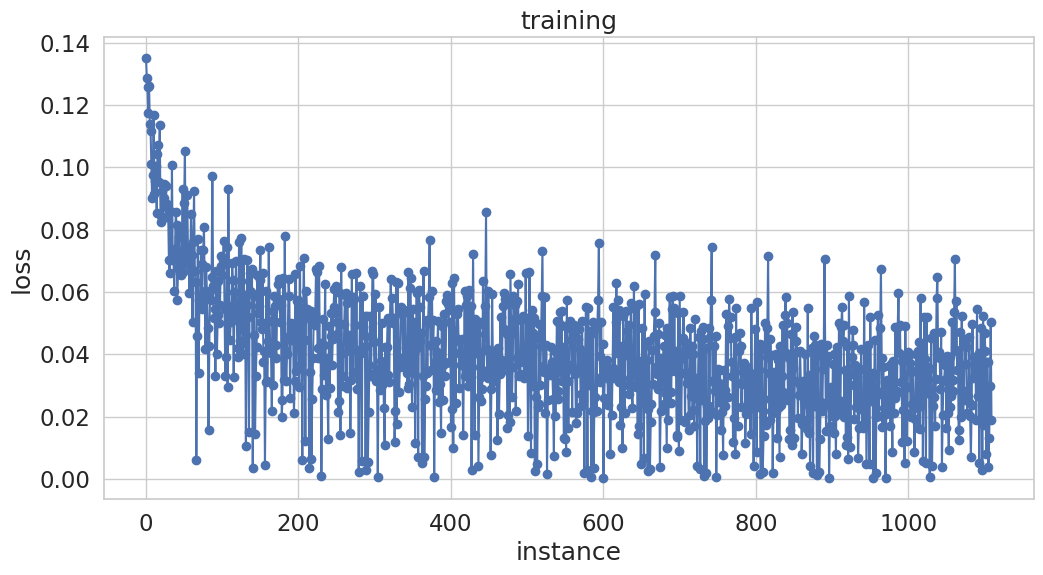

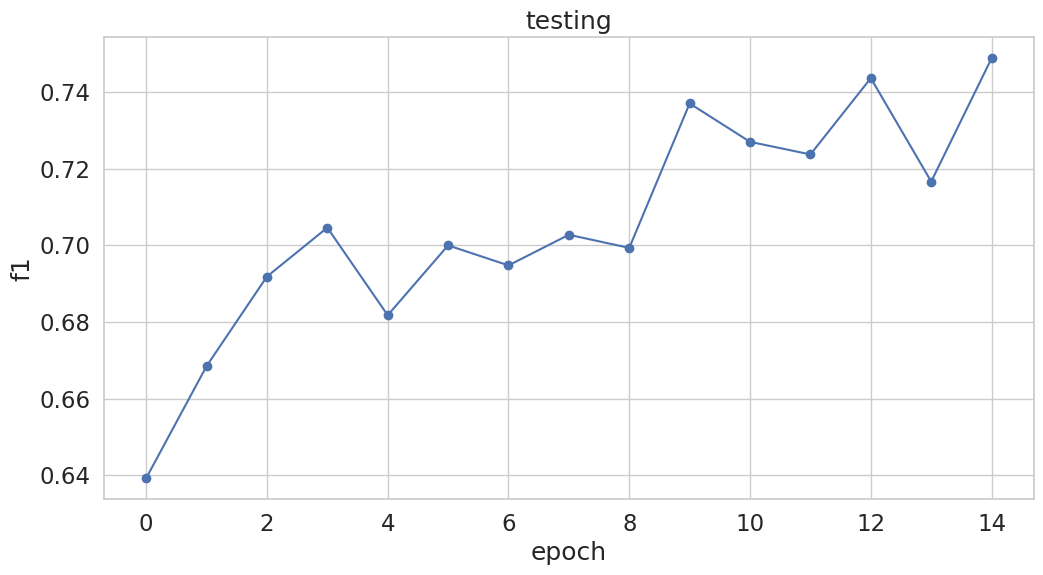

100%|██████████| 30/30 [00:16<00:00,  1.81it/s]


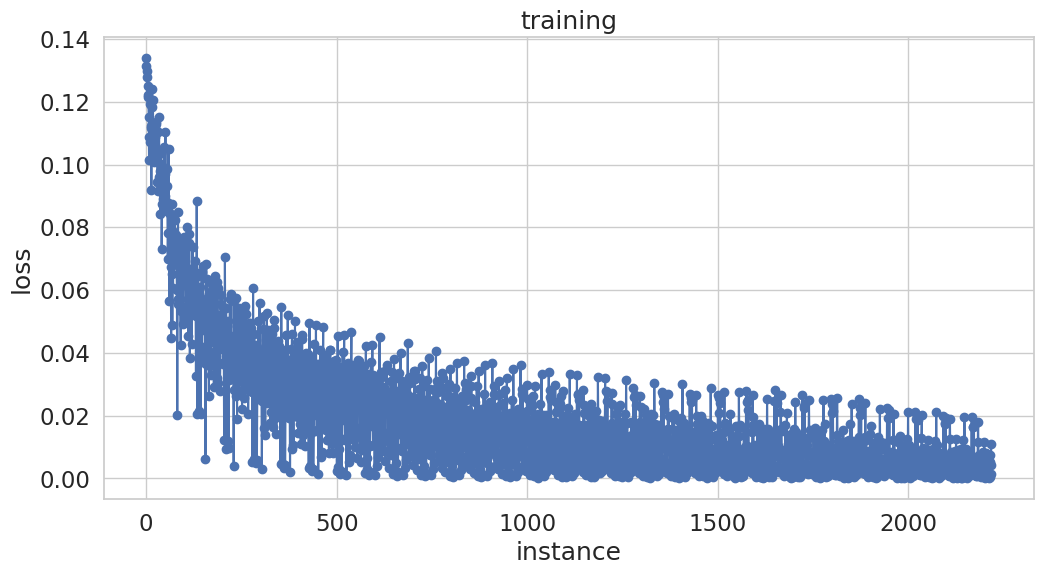

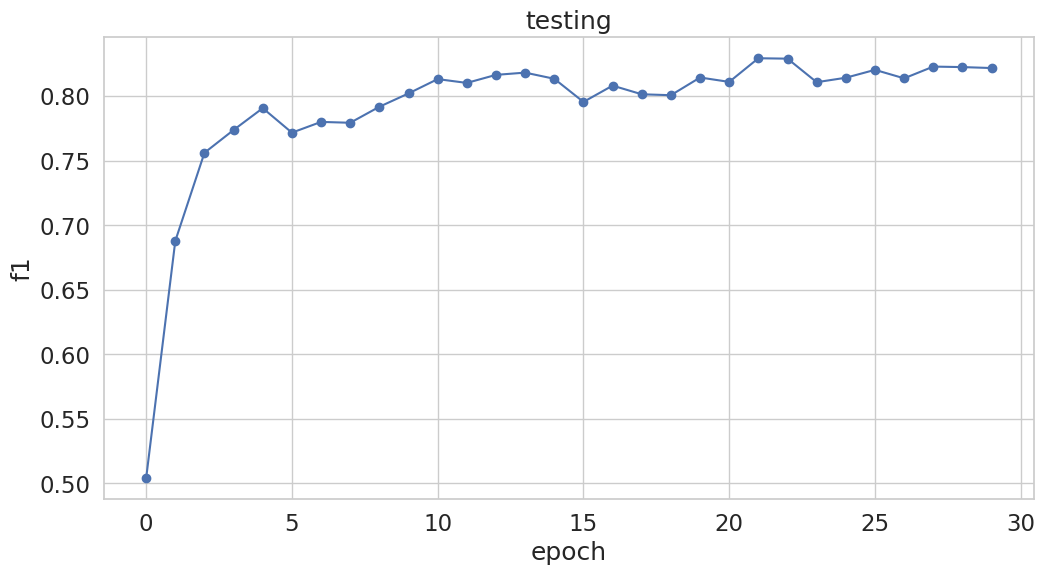

100%|██████████| 30/30 [00:18<00:00,  1.60it/s]


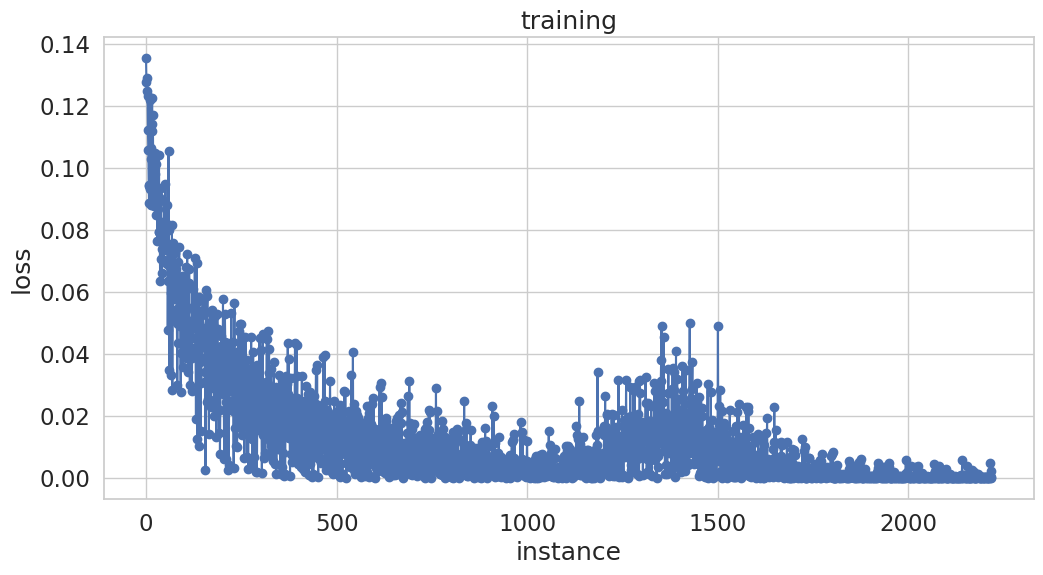

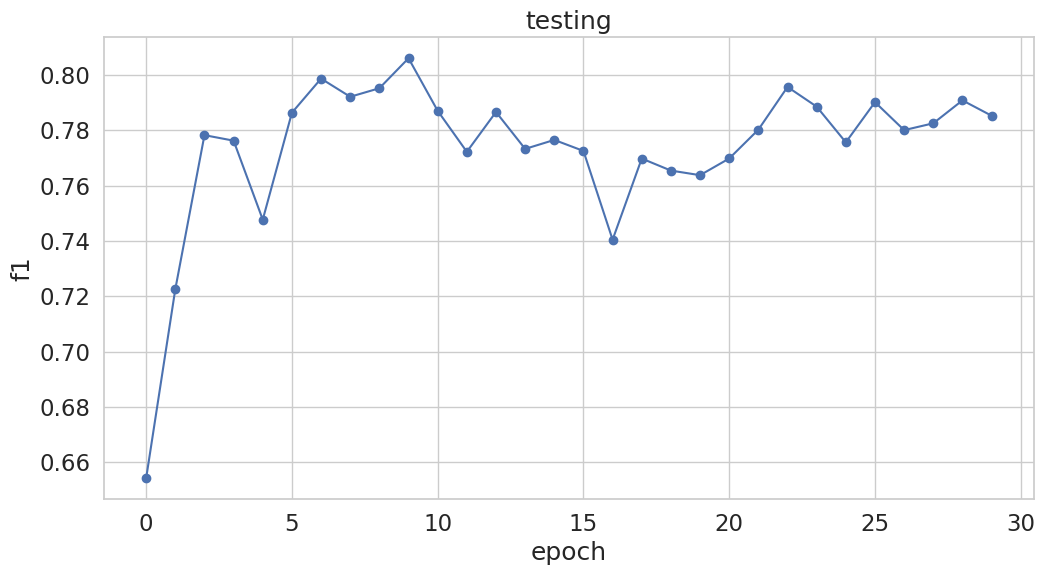

100%|██████████| 40/40 [00:22<00:00,  1.74it/s]


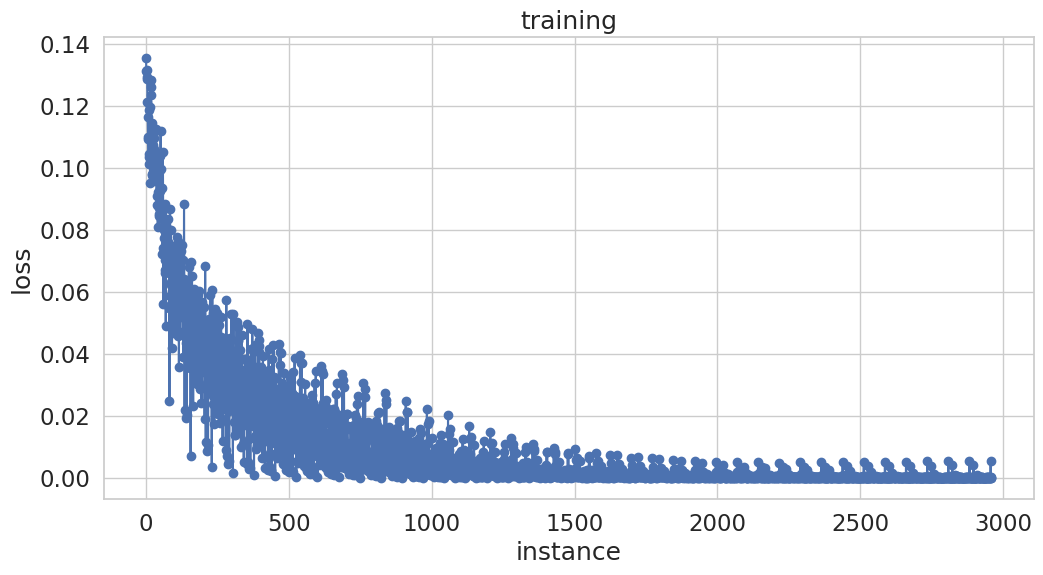

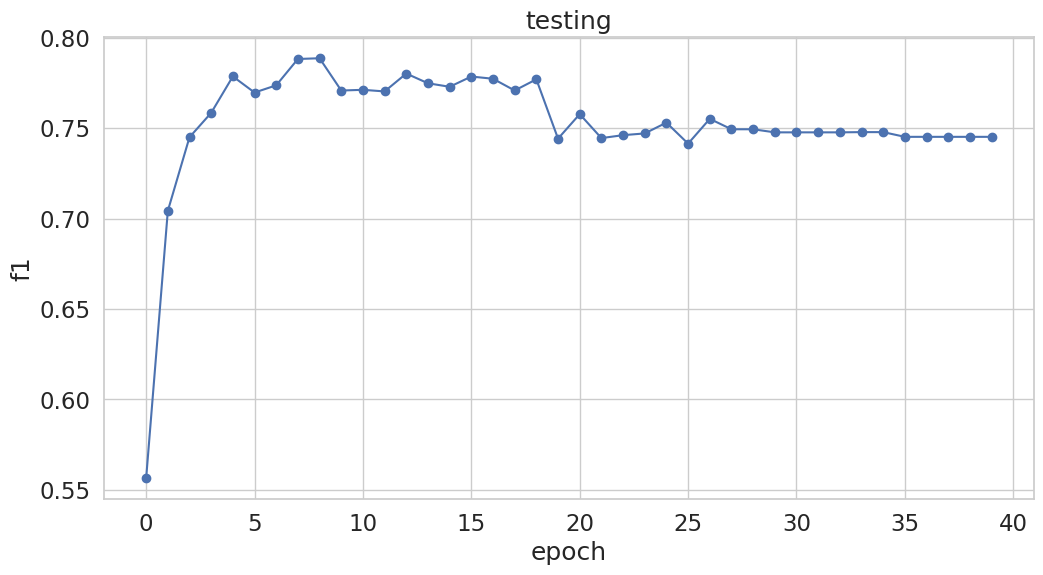

100%|██████████| 40/40 [00:23<00:00,  1.70it/s]


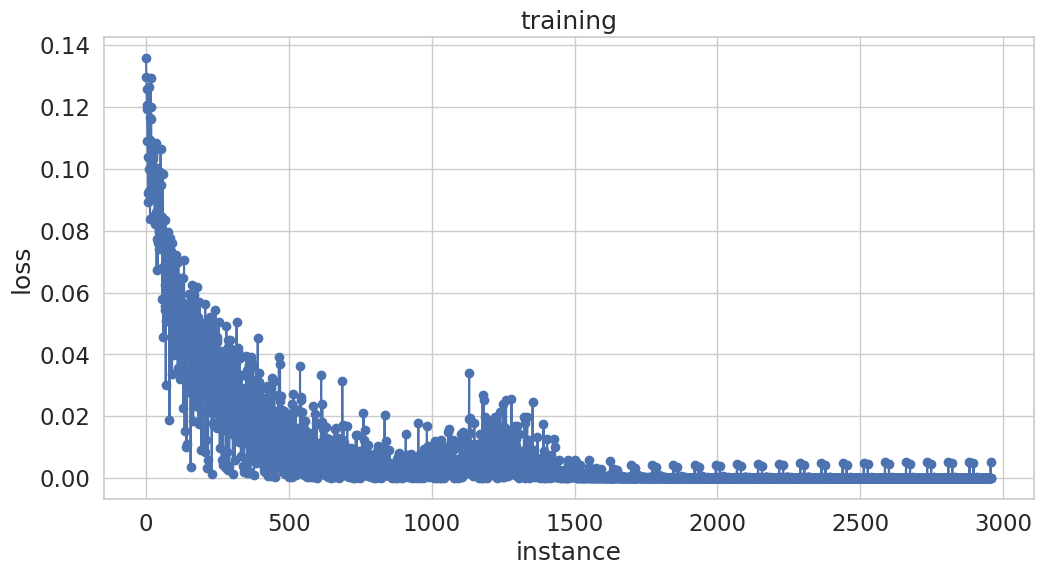

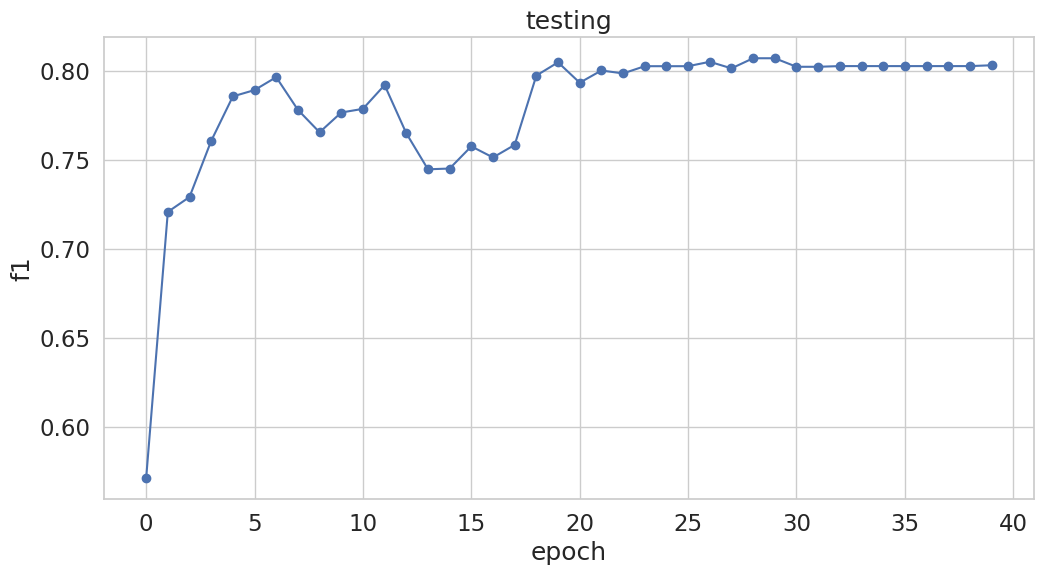

,hidden,lr,epochs,f1
1,20,0.010,30,0.822
4,100,0.005,40,0.803
2,50,0.010,30,0.785
0,10,0.050,15,0.749
3,50,0.005,40,0.745


In [94]:
# trying a few settings. bigger hidden layer usually needs a smaller learning rate
results = []
for hidden, lr_, epochs in [(10, .05, 15), (20, .01, 30), (50, .01, 30), (50, .005, 40), (100, .005, 40)]:
    torch.random.manual_seed(42)
    rnn = RNN(50, hidden, len(states), states)
    train_rnn(rnn, rnn_data_embed_train, rnn_data_embed_test, epochs=epochs, learning_rate=lr_)
    f1 = evaluate_rnn(rnn, rnn_data_embed_test, verbose=False)
    results.append({'hidden': hidden, 'lr': lr_, 'epochs': epochs, 'f1': round(f1, 3)})

pd.DataFrame(results).sort_values('f1', ascending=False)


Hmm...at first glance it doesn't seem worth using an RNN with this data. But, maybe we haven't tuned it properly?

Play around with the learning rate, hidden_size, and number of epochs for the final RNN model above. What is the best "weighted avg" F1 you can obtain? What are the values of the tuning parameters you use? One tip -- as you increase hidden size, you may need to reduce the learning rate.

The best weighted avg F1 I got was 0.822, with hidden size 20, learning rate 0.01 and 30 epochs. The default settings of 10 hidden units, learning rate 0.05 and 15 epochs got 0.749.

Dropping the learning rate to 0.01 and training longer made the biggest difference. That alone took F1 from 0.749 to 0.822. Making the hidden layer bigger didn't really help. 50 hidden units at 0.01 got 0.785 and 100 at 0.005 got 0.803, and both are worse than 20. The worst run was 50 hidden at 0.005 with 0.745. I think that learning rate was too small to get anywhere in 40 epochs.

The test set is tiny though. It's only 10 sentences and 232 words, so one or two words can move F1 a lot, and I wouldn't trust small gaps between settings. But the tuned RNN still beats the HMM at 0.75 and the one hot RNN at 0.70. So the RNN wasn't bad here. It just needed tuning.
